In [43]:
''' 
@Time        : edited 07/2026
@Author      : Lizzie Flores
@File        : test_01_rrlyrae
@Description : light curve fitting for RR_lyrae using mean template
'''
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import least_squares


#### Directories

In [44]:
"Loading in the light curves"

#folder that holds all my test stuff
parent_dir = "/Users/lizzieflores/Documents/tess_variables/rr_sandbox/"
#star list text file
file_names_path = "/Users/lizzieflores/Documents/tess_variables/rr_sandbox/rr_lc.txt"
#folder of data
file_data_path = "/Users/lizzieflores/Documents/tess_variables/rr_sandbox/test_data/"
#folder to write each star's values to
output_dir = "/Users/lizzieflores/Documents/tess_variables/rr_sandbox/saved_vals/"
#creating readable file for the stars
star_list = pd.read_csv(file_names_path, names=["file_name", "period"], sep=" ")
# file to write to
slope_file = os.path.join(parent_dir, "rr_slopes.txt")
with open(slope_file, mode="w", encoding="utf-8") as f:
    pass

#### Phase Folding/Mean Functions

In [45]:
#overlapping the phases for the light curves
def phase_fold(time, period, t0=None):
    if t0 is None:
        t0 = lc["time"].min()
    phase = ((time - t0) / period) % 1
    return phase

#getting the mean light curve by binning then calculating the mean mag and error for each bin
def mean_lc(lc, nbins=130):
    bins = np.linspace(0, 1, nbins + 1)
    lc = lc.copy()
    lc["bin"] = np.digitize(lc["phase"], bins)
    mean_rows = []
    for _, group in lc.groupby("bin"):
        if len(group) == 0:
            continue
        phase = group["phase"].mean()
        mag = group["mag"].values
        err = group["err"].values
        
        #included weights to account for differences in errors
        weights = 1 / err**2
        weighted_mag = np.sum(weights*mag) / np.sum(weights)
        weighted_err = np.sqrt(1 / np.sum(weights))
        mean_rows.append({"phase": phase, "mag": weighted_mag, "err": weighted_err, "n": len(group)})
    mean_curve = pd.DataFrame(mean_rows)
    return mean_curve
#template function to interpolate the mean curve
def mean_template(mean_curve):
    template = interp1d(mean_curve["phase"], mean_curve["mag"], kind="cubic", fill_value="extrapolate")
    return template

#model function to fit the template to the light curve data
def template_model(phase, template, phase_shift, amp_scale, mag_offset):
    shifted_phase = (phase + phase_shift) % 1.0
    model_mag = amp_scale * template(shifted_phase) + mag_offset
    model_mag += mag_offset
    return model_mag

### Fourier Template Functions

In [1]:
# #making a fourier template for the mean light curve
# def fourier_template(mean_curve, order=7):
#     phase = mean_curve["phase"].values
#     mag = mean_curve["mag"].values
#     err = mean_curve["err"].values

#     #creating the fourier
#     X = np.ones((len(phase), 1))
#     for k in range(1, order + 1):
#         X = np.column_stack((X, np.cos(2*np.pi*k*phase), np.sin(2*np.pi*k*phase)))

#     #including weights
#     weights = 1 / err**2
#     sqrt_weights = np.sqrt(weights)
#     X_weighted = X * sqrt_weights[:, None]
#     y_weighted = mag * sqrt_weights
#     #
#     coeff = np.linalg.lstsq(X_weighted, y_weighted, rcond=None)[0]
#     model_phase = np.linspace(0, 1, 1000)
#     X_model = np.ones((len(model_phase),1))
#     #
#     for k in range(1, order + 1):
#         X_model = np.column_stack(
#             (X_model, np.cos(2*np.pi*k*model_phase), np.sin(2*np.pi*k*model_phase)))
#     model_mag = X_model @ coeff
#     return coeff, model_phase, model_mag

# #finding the maximum time of light using the fourier template
# def max_light(model_phase, model_mag):
#     index = np.argmin(model_mag)
#     max_phase = model_phase[index]
#     max_mag = model_mag[index]
#     return max_phase, max_mag

# def find_extrema(coeff, n_points=10000):
#     phase_grid = np.linspace(0,1,n_points)
#     model_mag = fourier_template(phase_grid, coeff)
#     max_index = np.argmin(model_mag)
#     min_index = np.argmax(model_mag)

#     return (phase_grid[max_index], phase_grid[min_index], model_mag[max_index], model_mag[min_index])

#### Plots

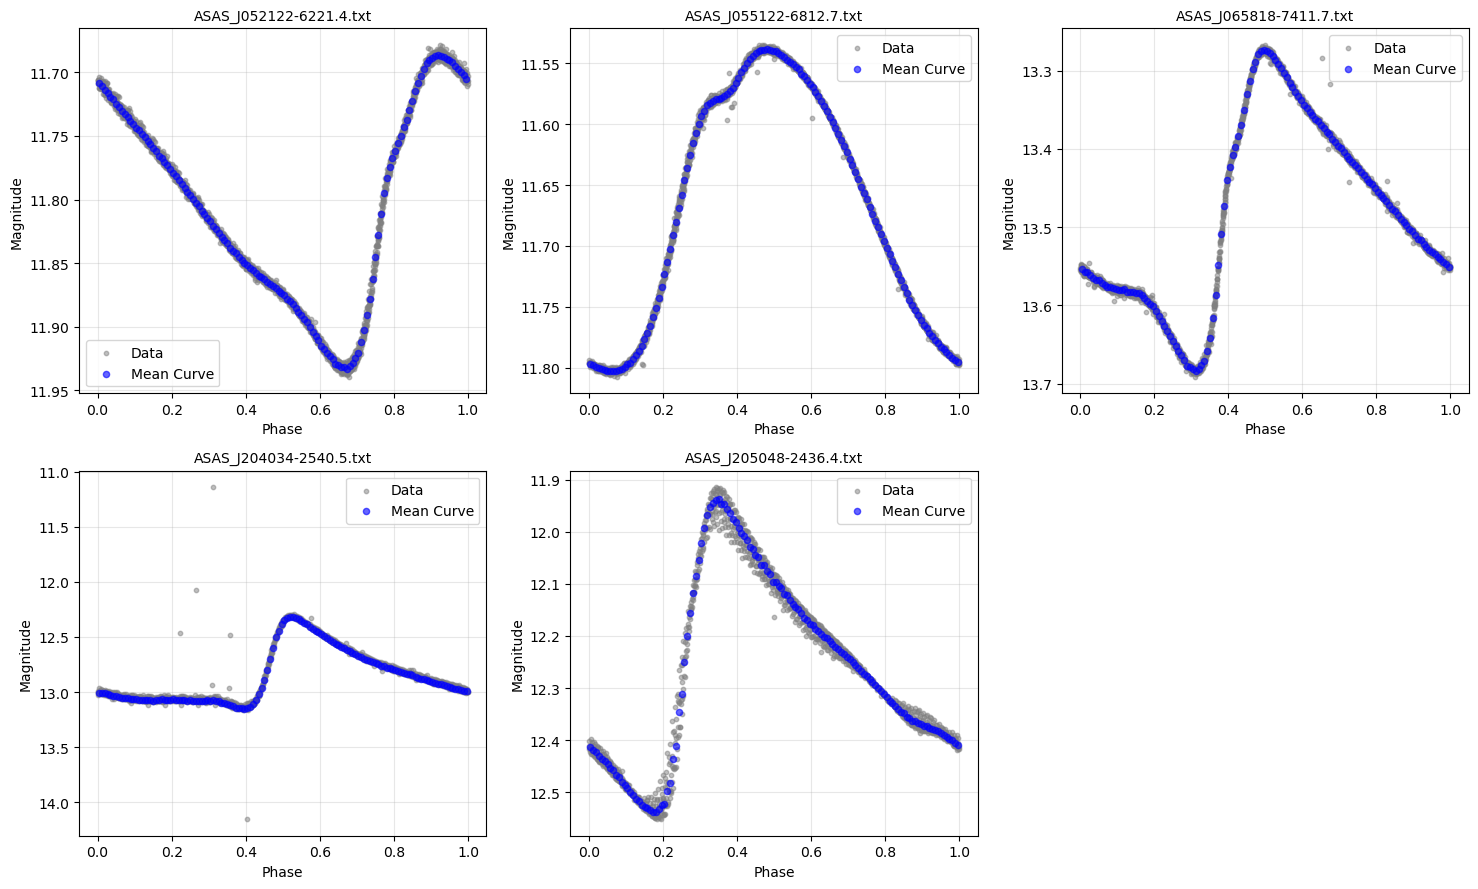

In [46]:
"Plotting the phase folded light curves with their mean"
fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.flatten()
plot_count = 0
plt.rcParams['axes.axisbelow'] = True

for idx, row in star_list.iterrows():
    #loading in the data
    curr_star = row.file_name
    period = row.period
    lc = pd.read_csv(file_data_path + curr_star, names=["time", "mag", "err"], sep=" ")
    
    #calling the function to stack the phases
    lc["phase"] = phase_fold(lc["time"], period)
    lc = lc.sort_values("phase").reset_index(drop=True)
    #finding the mean of the curves
    mean_curve = mean_lc(lc)
    
    #plotting
    ax = axes[plot_count]
    ax.scatter(lc["phase"], lc["mag"], color="gray", s=10, alpha=0.5, label="Data")
    ax.scatter(mean_curve["phase"], mean_curve["mag"], color="blue", s=20, alpha=0.6, label="Mean Curve")
    ax.invert_yaxis()
    ax.set_xlabel("Phase")
    ax.set_ylabel("Magnitude")
    ax.set_title(curr_star, fontsize=10)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plot_count += 1
#current file contains 5 light curves, remove to include 6th etc
axes[5].remove()


,Pulse,Maximum Mag,Maximum Time,Predicted Time
0,42,"[11.936890030470979, 11.936890030470979, 11.93...","[2458325.5521954545, 2458326.2057554545, 24583...",2.458353e+06
1,60,"[12.313804349477087, 12.313804349477087, 12.31...","[2458325.5628, 2458326.0236, 2458326.4844, 245...",2.458353e+06
2,86,"[11.686279540843362, 11.686279540843362, 11.68...","[2458325.9208145, 2458326.5705145, 2458327.220...",2.458382e+06
3,93,"[13.273286075986977, 13.273286075986977, 13.27...","[2458325.62171, 2458326.22283, 2458326.82395, ...",2.458382e+06
4,174,"[11.538235151159107, 11.538235151159107, 11.53...","[2458325.47816, 2458325.79994, 2458326.12172, ...",2.458381e+06


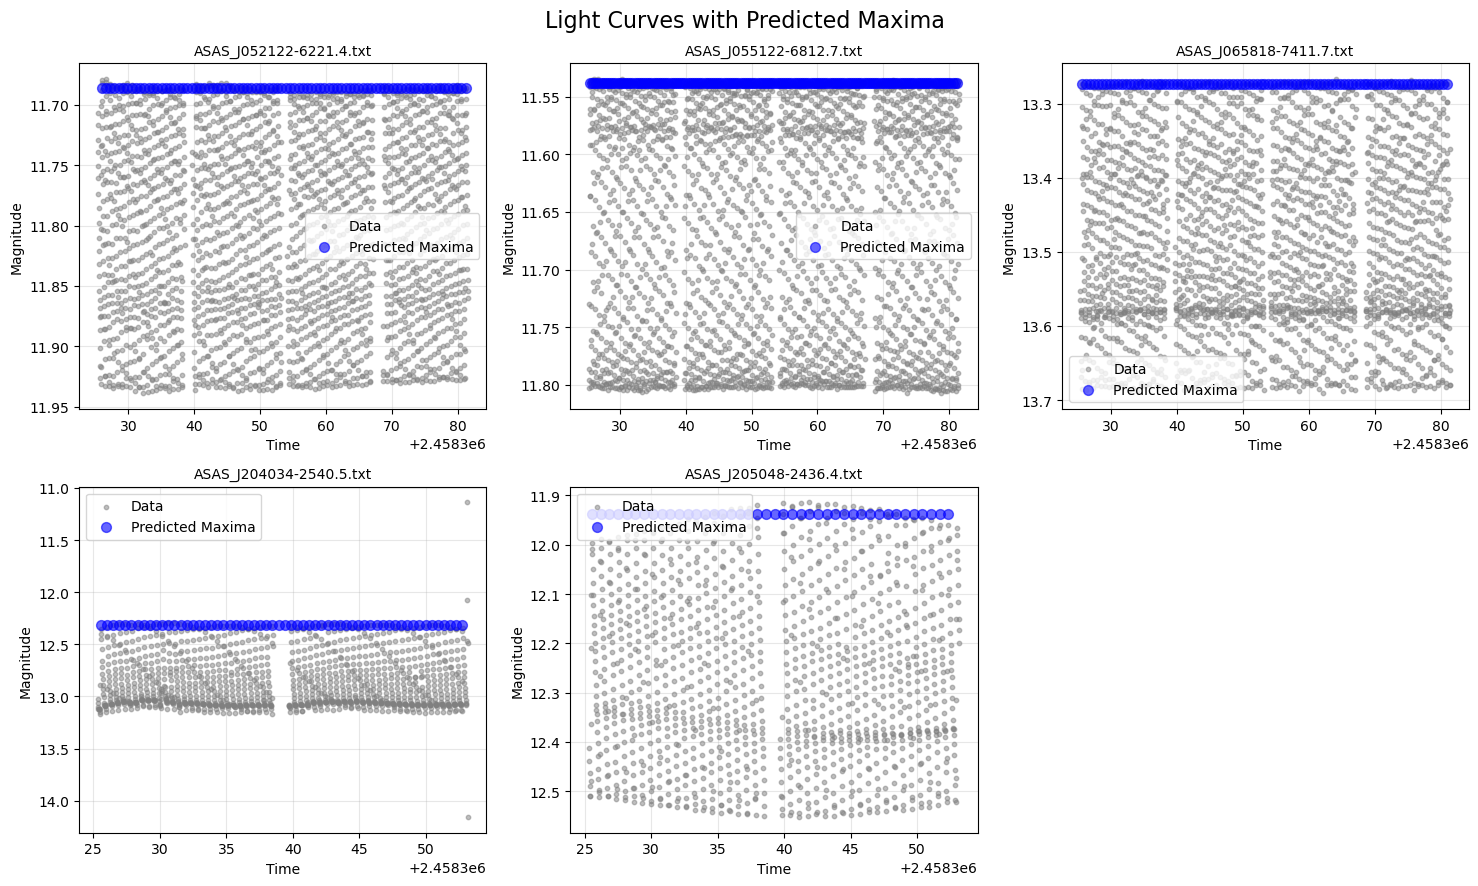

In [47]:
"Plotting the light curves along time with the predicted maxima"
fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.flatten()
plot_count = 0
plt.rcParams['axes.axisbelow'] = True
results = []

for idx, row in star_list.iterrows():
    #loading in the data
    curr_star = row.file_name
    period = row.period
    lc = pd.read_csv(file_data_path + curr_star, names=["time", "mag", "err"], sep=" ")
    
    #calling the function to stack the phases
    lc["phase"] = phase_fold(lc["time"], period)
    lc = lc.sort_values("phase").reset_index(drop=True)
    #finding the mean of the curves
    mean_curve = mean_lc(lc)

    #new block - going back into time to find the predicted maxima
    max_idx = np.argmin(mean_curve["mag"])
    phase_max = mean_curve["phase"].iloc[max_idx]
    template_max_mag = mean_curve["mag"].iloc[max_idx]
    max_mag_template = mean_curve["mag"].iloc[max_idx]
    max_idx = np.argmin(mean_curve["mag"])

    #getting the predicted maxima times based on the phase of maximum light and the period of the star
    t0 = lc["time"].min()
    tf = lc["time"].max()
    n_cycles = int(np.floor((tf - t0) / period))
    max_times = []

    #looping for the maximums
    for i in range(n_cycles):
        cycle_start = t0 + i * period
        max_time = cycle_start + phase_max * period
        predicted_time = max_time + period
        max_times.append(max_time)
    max_mags = np.full(len(max_times), template_max_mag)

    #plotting
    ax = axes[plot_count]
    ax.scatter(lc["time"], lc["mag"], color="gray", s=10, alpha=0.5, label="Data")
    ax.scatter(max_times, max_mags, color="blue", s=50, alpha=0.6, label="Predicted Maxima")
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
    ax.set_title(curr_star, fontsize=10)
    fig.suptitle("Light Curves with Predicted Maxima", fontsize=16)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plot_count += 1
    #results
    results.append({"Pulse": i + 1, "Maximum Mag": max_mags, "Maximum Time": max_times, "Predicted Time": predicted_time})
#current file contains 5 light curves, remove to include 6th etc
axes[5].remove()

#storing the results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Pulse").reset_index(drop=True)
display(results_df)
results_df.to_csv(output_dir + curr_star.replace(".txt", "_maxima.csv"), index=False)

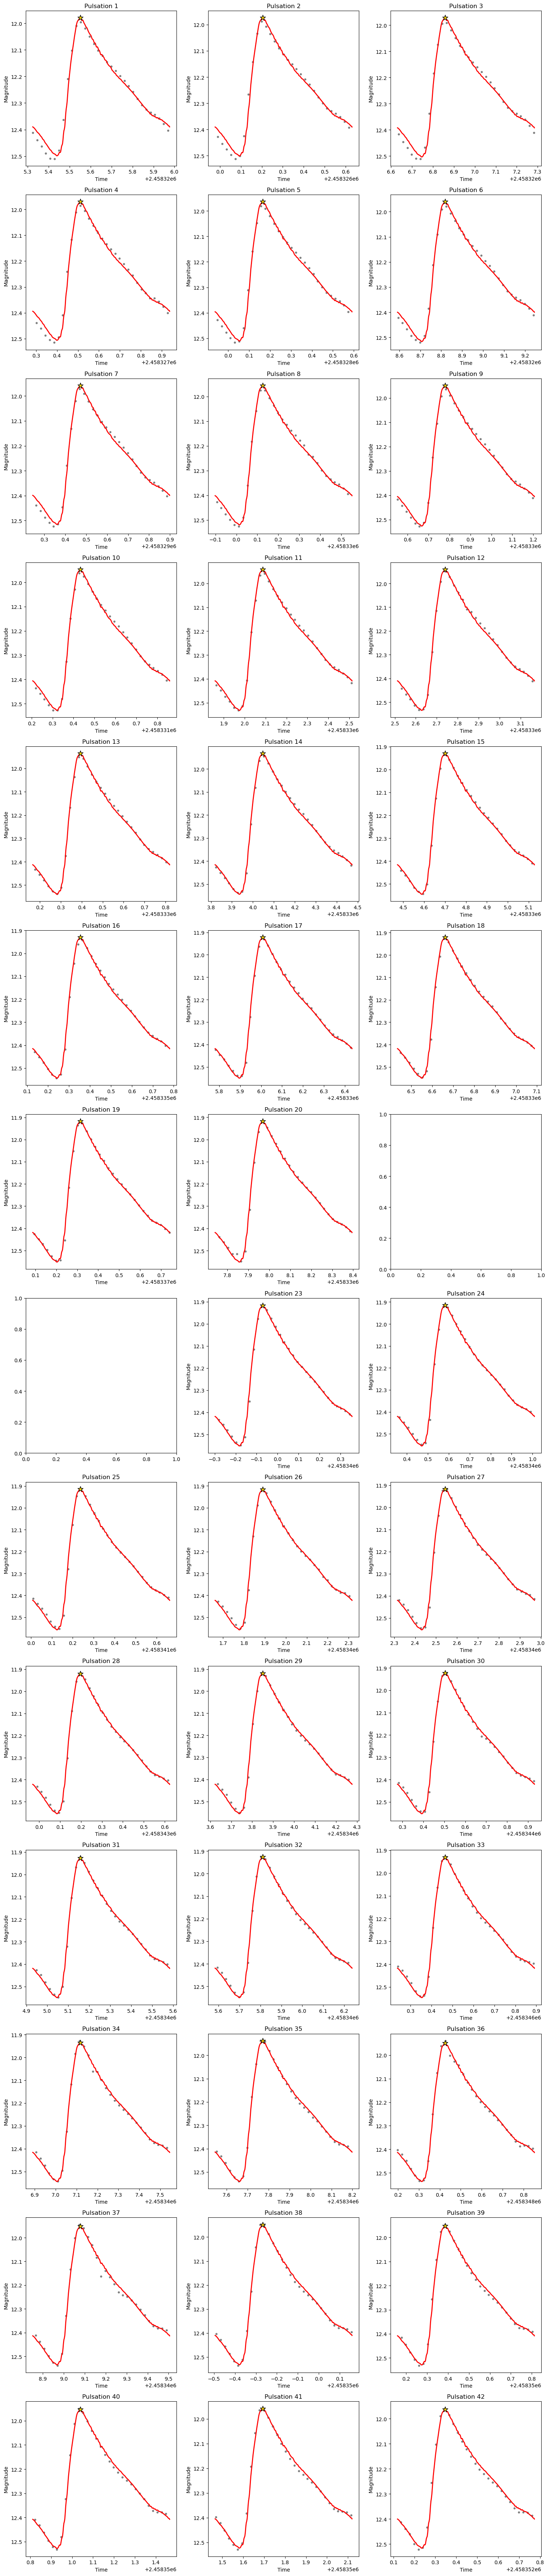

,Data Point,Pulse,Maximum Mag,Maximum Time,Predicted Time
0,12,1,11.979568,2.458326e+06,2.458326e+06
1,43,2,11.974052,2.458326e+06,2.458327e+06
2,75,3,11.972281,2.458327e+06,2.458328e+06
3,106,4,11.970108,2.458328e+06,2.458328e+06
4,137,5,11.963805,2.458328e+06,2.458329e+06
5,169,6,11.960521,2.458329e+06,2.458329e+06
6,200,7,11.958575,2.458329e+06,2.458330e+06
7,232,8,11.956315,2.458330e+06,2.458331e+06
8,263,9,11.949108,2.458331e+06,2.458331e+06
9,294,10,11.946913,2.458331e+06,2.458332e+06


In [48]:
"Plotting the model over the real data"
#loading in the star (CHANGE THE INDEX FOR A NEW STAR)
star_index = 4
curr_star = star_list.iloc[star_index]["file_name"]
period = star_list.iloc[star_index]["period"]
lc = pd.read_csv(file_data_path + curr_star, names=["time", "mag", "err"], sep=" ")
t0 = lc["time"].min()
lc["pulse"] = np.floor((lc["time"] - t0) / period).astype(int) + 1
lc["data_point"] = np.arange(1, len(lc) + 1)

#template
lc["phase"] = phase_fold(lc["time"], period)
lc = lc.sort_values("phase").reset_index(drop=True)
mean_curve = mean_lc(lc)
template = mean_template(mean_curve)
#finding the max light and its phase
max_index = np.argmin(mean_curve["mag"])
phase_max = mean_curve["phase"].iloc[max_index]
t0 = lc["time"].min()
tf = lc["time"].max()
n_cycles = int(np.floor((tf-t0)/period))

#scaling model
def scaled_model(time,cycle_start, period, A, C):
    phase = ((time - cycle_start)/period) % 1
    return A*template(phase)+C
#residuals for least squares
def residuals(params, cycle, cycle_start):
    A, C = params
    model = scaled_model(cycle["time"], cycle_start, period, A, C)
    return (cycle["mag"]-model)/cycle["err"]

#plotting
ncols = 3
nrows = int(np.ceil(n_cycles/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes = axes.flatten()
results = []

#looping through the model
for i in range(n_cycles):
    cycle_start = t0 + i*period
    cycle_end = cycle_start + period
    cycle = lc[(lc["time"]>=cycle_start) & (lc["time"]<cycle_end)].copy()

    if len(cycle) < 10:
        continue
    #least squares fitting
    fit = least_squares(residuals, x0=[1.0,0.0], args=(cycle,cycle_start))
    A,C = fit.x

    #scaling
    model_time = np.linspace(cycle_start, cycle_end, 300)
    model_mag = scaled_model(model_time, cycle_start, period, A, C)
    model_phase = ((model_time-cycle_start)/period)%1

    #max light and phase
    idx_max = np.argmin(model_mag)
    max_time = model_time[idx_max]
    max_mag = model_mag[idx_max]
    predicted_time = max_time + period
    data_point = cycle.loc[(cycle["time"] - max_time).abs().idxmin(), "data_point"]
    results.append({"Data Point": data_point, "Pulse": i+1, "Maximum Mag": max_mag, "Maximum Time": max_time, "Predicted Time": predicted_time})
    #plotting
    ax = axes[i]
    ax.scatter(cycle["time"], cycle["mag"], s=10, color="gray", label="Observed")
    ax.plot(model_time, model_mag, color="red", linewidth=2, label="Scaled Model")
    ax.scatter(max_time, max_mag, marker="*", s=120, color="gold", edgecolor="black", zorder=20, label="Maximum")
    ax.invert_yaxis()
    ax.set_title(f"Pulsation {i+1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Magnitude")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Pulse").reset_index(drop=True)
display(results_df)

In [49]:
comparison = []

for i in range(n_cycles):
    cycle_start = t0 + i * period
    cycle_end = cycle_start + period
    cycle = lc[(lc["time"] >= cycle_start) & (lc["time"] < cycle_end)].copy()

    if len(cycle) < 10:
        continue

    observed_idx = cycle["mag"].idxmin()
    observed_max_time = cycle.loc[observed_idx, "time"]
    observed_max_mag = cycle.loc[observed_idx, "mag"]

    fit = least_squares(residuals, x0=[1.0, 0.0], args=(cycle, cycle_start))
    A, C = fit.x

    model_time = np.linspace(cycle_start, cycle_end, 5000)
    model_mag = scaled_model(model_time, cycle_start, period, A, C)
    model_idx = np.argmin(model_mag)
    model_max_time = model_time[model_idx]
    model_max_mag = model_mag[model_idx]

    time_difference = observed_max_time - model_max_time
    comparison.append({"pulse": i + 1, "observed max time": observed_max_time, "model max time": model_max_time, "time difference": time_difference,
                       "observed max mag": observed_max_mag, "model max mag": model_max_mag})

comparison_df = pd.DataFrame(comparison)
display(comparison_df.style.format({"observed max time":"{:.6f}", "model max time":"{:.6f}", "time difference":"{:.6f}",
                                    "observed max mag":"{:.5f}", "model max mag":"{:.5f}"}))

,pulse,observed max time,model max time,time difference,observed max mag,model max mag
0,1,2458325.552680,2458325.550351,0.002329,11.99570,11.97950
1,2,2458326.198520,2458326.203911,-0.005391,11.98810,11.97398
2,3,2458326.865180,2458326.857471,0.007709,11.99190,11.97221
3,4,2458327.511020,2458327.511031,-0.000011,11.98500,11.97003
4,5,2458328.156850,2458328.164591,-0.007741,11.98010,11.96373
5,6,2458328.823520,2458328.818151,0.005369,11.97870,11.96044
6,7,2458329.469350,2458329.471711,-0.002361,11.97150,11.95850
7,8,2458330.115180,2458330.125271,-0.010091,11.97490,11.95624
8,9,2458330.781850,2458330.778831,0.003019,11.96440,11.94903
9,10,2458331.427690,2458331.432391,-0.004701,11.96180,11.94683


In [15]:
display(lc.sort_values("time")[["data_point", "time", "mag", "err", "pulse"]])

,data_point,time,mag,err,pulse
0,1,2.458325e+06,11.7070,0.0009,1
81,2,2.458325e+06,11.7169,0.0009,1
162,3,2.458325e+06,11.7287,0.0009,1
244,4,2.458325e+06,11.7391,0.0009,1
326,5,2.458325e+06,11.7507,0.0010,1
...,...,...,...,...,...
822,2523,2.458381e+06,11.8233,0.0009,87
904,2524,2.458381e+06,11.8364,0.0008,87
986,2525,2.458381e+06,11.8451,0.0008,87
1067,2526,2.458381e+06,11.8546,0.0009,87


In [ ]:
lc.sort_values("time").to_csv(output_dir + curr_star.replace(".txt", "_pulses.csv"), 
                              index=False, columns=["data_point", "time", "mag", "err", "pulse"])